In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import re
import matplotlib.pyplot as plt
import numpy as np



/Users/jesucastin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:

def entropy(array):
    _, counts = np.unique(array, return_counts=True)
    probabilities = counts / len(array)
    shannon_entropy = -np.sum(probabilities * np.log2(probabilities))
    
    return shannon_entropy

In [4]:
pre_psi_rotamers_df=pd.read_csv("../../../data/dihedrals/net_communication/preLC3B_OPLS/BB/PSI/ROTAMERS/preLC3B_OPLS_psi_rotamers_all.csv", index_col=0)
pre_phi_rotamers_df=pd.read_csv("../../../data/dihedrals/net_communication/preLC3B_OPLS/BB/PHI/ROTAMERS/preLC3B_OPLS_phi_rotamers_all.csv", index_col=0)


pre_chi1_rotamers_df=pd.read_csv("../../../data/dihedrals/net_communication/preLC3B_OPLS/SC/CHI1/ROTAMERS/preLC3B_OPLS_chi1_rotamers.csv", index_col=0)


In [5]:
pwd

'/Volumes/Seagate Hub/LC3_conformations_scripts_data/scripts/dihedrals/dihedral_entropy_calculations'

In [6]:
bnd_psi_rotamers_df=pd.read_csv("../../../data/dihedrals/net_communication/LC3B_P62_INCLUDED/BB/PSI/ROTAMERS/LC3B_P62_INCLUDED_psi_rotamers_all.csv", index_col=0)
bnd_phi_rotamers_df=pd.read_csv("../../../data/dihedrals/net_communication/LC3B_P62_INCLUDED/BB/PHI/ROTAMERS/LC3B_P62_INCLUDED_phi_rotamers_all.csv", index_col=0)

bnd_chi1_rotamers_df=pd.read_csv("../../../data/dihedrals/net_communication/LC3B_P62_INCLUDED/SC/CHI1/ROTAMERS/LC3B_P62_INCLUDED_chi1_rotamers.csv", index_col=0)


In [7]:
def num_ext(DF, angle):
    FORM_dih_sel_col=[]
    for i in DF.columns:
        j=i.split('.')[0].replace(angle,'')
        t_ls=re.findall(r'\d+', j)
        t=int(''.join(t_ls))
        FORM_dih_sel_col.append(t)
    return(FORM_dih_sel_col)

def entropy_ret(rot_dat,angle_):
    rot_dat_ent_df=pd.DataFrame()
    rot_dat_ent=[]
    for i in rot_dat.columns:

        ls=rot_dat[i].to_numpy()
        rot_dat_ent.append(entropy(ls))
    
    rot_dat_ent_df['Residues']=num_ext(rot_dat, angle_)
    rot_dat_ent_df[angle_]= rot_dat_ent   
    return rot_dat_ent_df

In [8]:
pre_psi_entropy=entropy_ret(pre_psi_rotamers_df, 'psi')
pre_phi_entropy=entropy_ret(pre_phi_rotamers_df, 'phi')


pre_chi1_entropy=entropy_ret(pre_chi1_rotamers_df, 'chi1')
# pre_chi2_entropy=entropy_ret(pre_chi2_rotamers_df, 'chi2')
# pre_chi3_entropy=entropy_ret(pre_chi3_rotamers_df, 'chi3')
# pre_chi4_entropy=entropy_ret(pre_chi4_rotamers_df, 'chi4')


pre_entropy_merger1=pd.merge(pre_psi_entropy, pre_phi_entropy, on='Residues', how='outer')
pre_entropy_merger2=pd.merge(pre_entropy_merger1, pre_chi1_entropy, on='Residues', how='outer')
# pre_entropy_merger2=pd.merge(pre_entropy_merger2, pre_chi2_entropy, on='Residues', how='outer')
# pre_entropy_merger2=pd.merge(pre_entropy_merger2, pre_chi3_entropy, on='Residues', how='outer')
# pre_entropy_merger2=pd.merge(pre_entropy_merger2, pre_chi4_entropy, on='Residues', how='outer')

pre_entropy_merger2=pre_entropy_merger2.fillna(0)
pre_entropy_merger2

,Residues,psi,phi,chi1
0,1,0.242109,0.994710,1.062783
1,2,0.964763,-0.000000,0.215513
2,3,0.904758,0.386450,1.463197
3,4,0.797402,0.014644,0.677710
4,5,0.621834,0.097914,1.457166
...,...,...,...,...
120,121,0.631530,0.531883,1.151683
121,122,0.981568,0.004327,1.551311
122,123,0.576848,0.004327,1.168260
123,124,0.993309,0.243634,1.193351


In [9]:
bnd_psi_entropy=entropy_ret(bnd_psi_rotamers_df, 'psi')
bnd_phi_entropy=entropy_ret(bnd_phi_rotamers_df, 'phi')


bnd_chi1_entropy=entropy_ret(bnd_chi1_rotamers_df, 'chi1')
# bnd_chi2_entropy=entropy_ret(bnd_chi2_rotamers_df, 'chi2')
# bnd_chi3_entropy=entropy_ret(bnd_chi3_rotamers_df, 'chi3')
# bnd_chi4_entropy=entropy_ret(bnd_chi4_rotamers_df, 'chi4')


bnd_entropy_merger1=pd.merge(bnd_psi_entropy, bnd_phi_entropy, on='Residues', how='outer')
bnd_entropy_merger2=pd.merge(bnd_entropy_merger1, bnd_chi1_entropy, on='Residues', how='outer')
# bnd_entropy_merger2=pd.merge(bnd_entropy_merger2, bnd_chi2_entropy, on='Residues', how='outer')
# bnd_entropy_merger2=pd.merge(bnd_entropy_merger2, bnd_chi3_entropy, on='Residues', how='outer')
# bnd_entropy_merger2=pd.merge(bnd_entropy_merger2, bnd_chi4_entropy, on='Residues', how='outer')

bnd_entropy_merger2=bnd_entropy_merger2.fillna(0)
bnd_entropy_merger2 # NOTE: residues 120 to 126 are the p62 LIR residues 338 to 344

,Residues,psi,phi,chi1
0,1,0.961010,0.987483,1.135048
1,2,0.371848,-0.000000,0.735954
2,3,0.528058,0.771163,1.480312
3,4,0.400723,0.145053,0.766891
4,5,0.716838,0.011398,0.684566
...,...,...,...,...
121,122,0.488430,0.271862,-0.000000
122,123,0.369381,0.004327,1.160685
123,124,0.175519,-0.000000,1.029594
124,125,0.554334,-0.000000,1.028265


In [10]:
def net_ent_calc(state_df):
    net_entropy_norm_state=[]
    for a,i,j,k in zip(state_df['Residues'],
                    state_df['psi'],
                    state_df['phi'],
                    state_df['chi1']):

        ent_ls=[i,j,k]
    
        val=sum(ent_ls)
        if val ==0:
            net_entropy_norm_state.append(0)
        else:
            net_entropy_norm_state.append(val/max(ent_ls))

    return net_entropy_norm_state

In [11]:
pre_entropy_merger2['NET_ENTROPY']=net_ent_calc(pre_entropy_merger2)
bnd_entropy_merger2['NET_ENTROPY']=net_ent_calc(bnd_entropy_merger2)

In [12]:
#d entropy = BND ENTROPY - PRE ENTROPY
d_ent_pre_bnd=[]
for pre_res, pre_ent,\
bnd_res, bnd_ent in zip(pre_entropy_merger2.iloc[:119]['Residues'],
                        pre_entropy_merger2.iloc[:119]['NET_ENTROPY'],
                       bnd_entropy_merger2.iloc[:119]['Residues'],
                       bnd_entropy_merger2.iloc[:119]['NET_ENTROPY']): # comparing residues 1-119 of LC3B
    if pre_res!=bnd_res:
        print('WARNING!')
        break
    else:
        d_ent_pre_bnd.append(bnd_ent-pre_ent)

In [13]:
min(d_ent_pre_bnd), max(d_ent_pre_bnd)

(-1.460410537537052, 1.052397941261588)

/var/folders/pp/z1pgcq157pjgg48m2cg7wwkh0000gn/T/ipykernel_41014/3722844900.py:28: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar=plt.colorbar(f2rgb2, ticks=tk,shrink=0.3)


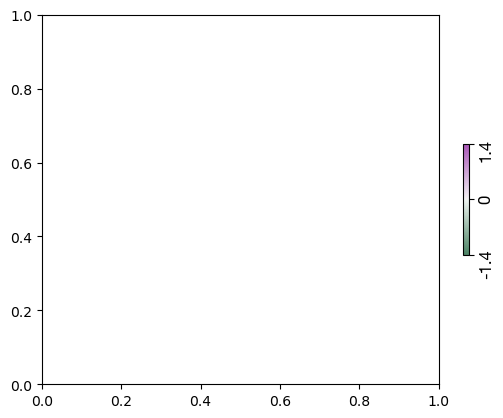

In [14]:

font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':12
   }
import matplotlib.cm as cm
import matplotlib.colors as colors
from pypalettes import load_cmap


mini=-1.4
maxi=1.4


cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True)
cmp=cmap
norm = colors.Normalize(vmin=mini, vmax=maxi)



f2rgb2 = cm.ScalarMappable(norm=norm, cmap=cmp)
f2rgb2.set_array([])
tk=np.linspace(mini, maxi, 3)
tk=np.round(tk,2)
cbar=plt.colorbar(f2rgb2, ticks=tk,shrink=0.3)
cbar.ax.set_yticks([-1.4, 0, 1.4],[-1.4, 0, 1.4],
                  rotation=90,fontdict=font)

plt.savefig('../../../plots/dihedrals/dihedral_entropy_calculations/d_SE_cbar_bnd_vs_pre.png',
                   dpi=450,transparent=True,
                   bbox_inches='tight')

In [15]:
col_ls_all=[]

for i,j in zip([i for i in range(1,120)],d_ent_pre_bnd):
    col=f2rgb2.to_rgba(j)[:3]
    col_ls_all.append(col)
    


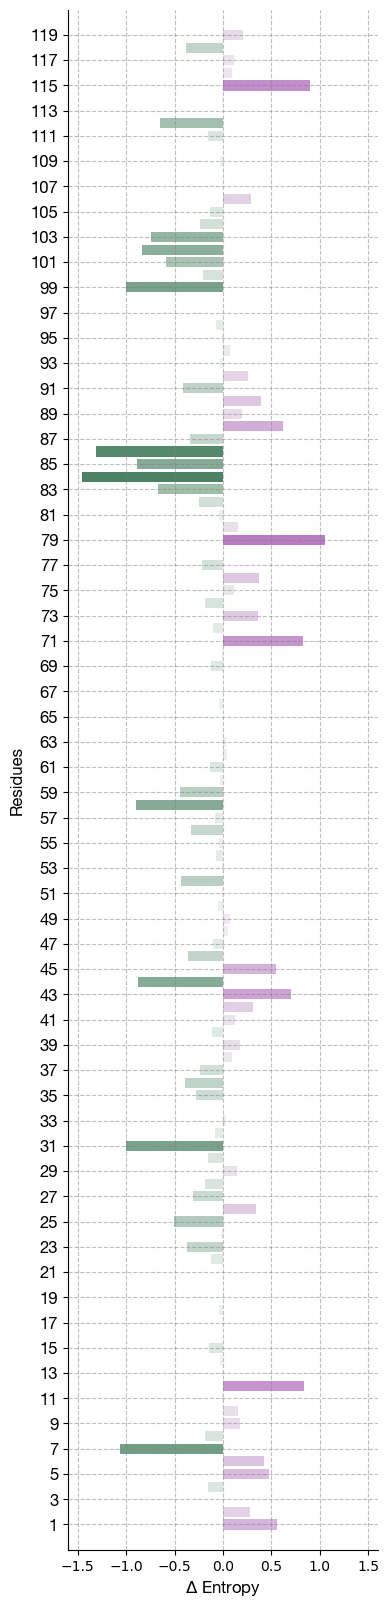

In [16]:
font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':12
   }

fig, ax = plt.subplots(figsize=(4,20))

ax.barh([i for i in range (1,120)],
         d_ent_pre_bnd,color=col_ls_all)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_visible(False)
# ax.spines['left'].set_visible(False)

# ax.set_yticks([])
# ax.set_xticks([])
#ax.set_xlim(0,15)

# ax.set_yticks([-1.5,-1,-0.5,0,0.5,1,1.5],
#              [-1.5,-1,-0.5,0,0.5,1,1.5],fontdict=font)

# ax.set_yticks([res_ for res_ in [i for i in range (1,120)]],
#               [str(res_) for res_ in [i for i in range (1,120)]]
#               ,fontdict=font, 
#              rotation=0)

ax.set_yticks([res_ for res_ in [i for i in range (1,120,2)]],
              [str(res_) for res_ in [i for i in range (1,120,2)]]
              ,fontdict=font, 
             rotation=0)

ax.set_xlabel('$\Delta$ Entropy', fontdict=font)
ax.set_ylabel('Residues', fontdict=font)
ax.set_xlim(-1.6, 1.6)
ax.set_ylim(-1, 121)

ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.5)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.5)
ax.xaxis.grid(which = 'minor',linestyle='dashed',alpha=0.5)
ax.yaxis.grid(which = 'minor',linestyle='dashed',alpha=0.5)


plt.savefig('../../../plots/dihedrals/dihedral_entropy_calculations/dihedral_entropy_SE_pre_bnd_BB_CHI1_considered_horizontal.png',
           dpi=450, transparent=True,
           bbox_inches='tight')

In [17]:
MEM_RES=[1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 37, 38, 39, 40, 41, 42, 43, 45, 46, 119]
pock_res=[19,23,32,34,51,53,108,35,52,54,55,58,63,66,67,70]
rest_res=[i for i in range(1,120) if i not in MEM_RES+pock_res]

In [18]:
def region_ord_returner(ord_data, region_ls):
    shift_ls=[]
    for i in region_ls:
        shift_val=ord_data[i-1]
        shift_ls.append(shift_val)
    return shift_ls

In [19]:
pre_ent_mtm=region_ord_returner(pre_entropy_merger2.iloc[:119]['NET_ENTROPY'].to_list(), MEM_RES)
pre_ent_bp=region_ord_returner(pre_entropy_merger2.iloc[:119]['NET_ENTROPY'].to_list(), pock_res)
pre_ent_rest=region_ord_returner(pre_entropy_merger2.iloc[:119]['NET_ENTROPY'].to_list(), rest_res)

In [20]:
bnd_ent_mtm=region_ord_returner(bnd_entropy_merger2.iloc[:119]['NET_ENTROPY'].to_list(), MEM_RES)
bnd_ent_bp=region_ord_returner(bnd_entropy_merger2.iloc[:119]['NET_ENTROPY'].to_list(), pock_res)
bnd_ent_rest=region_ord_returner(bnd_entropy_merger2.iloc[:119]['NET_ENTROPY'].to_list(), rest_res)

In [21]:
ord_region_wise=pd.DataFrame()
ord_region_wise["Residue"]=MEM_RES+pock_res+rest_res
ord_region_wise['Region']=['MTM' for i in pre_ent_mtm]+['BP' for i in pre_ent_bp]+['REST' for i in pre_ent_rest]
ord_region_wise['pre_ord']=pre_ent_mtm+ pre_ent_bp+ pre_ent_rest
ord_region_wise['bnd_ord']=bnd_ent_mtm+ bnd_ent_bp+ bnd_ent_rest
ord_region_wise

,Residue,Region,pre_ord,bnd_ord
0,1,MTM,2.163755,2.716663
1,2,MTM,1.223384,1.505260
2,3,MTM,1.882457,1.877667
3,4,MTM,1.868262,1.711672
4,5,MTM,1.493937,1.970881
...,...,...,...,...
114,114,REST,1.014772,1.005508
115,115,REST,1.098435,1.994838
116,116,REST,1.502937,1.591231
117,117,REST,1.882572,1.999724


In [22]:
# ord_region_wise.to_csv("../../../../LC3_paper_data_files_for_source_data_comp/delta_ent_bnd_vs_pre.csv")

/var/folders/pp/z1pgcq157pjgg48m2cg7wwkh0000gn/T/ipykernel_41014/770565282.py:15: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(x='Region', y='pre_ord', data=ord_region_wise,
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. P

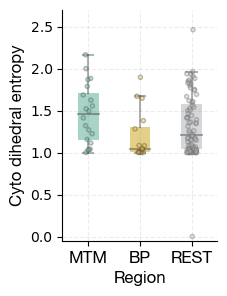

In [23]:
# Create the boxplot
fig, ax = plt.subplots(figsize=(2,3))
PROPS = {
    'boxprops':{ 'edgecolor':'none', 'alpha':0.6},
    'medianprops':{'color':'black','alpha':0.3},
    'whiskerprops':{'color':'black','alpha':0.3},
    'capprops':{'color':'black','alpha':0.3}}
col_ls=['#63C2A7','#EDBE1F','#B8BAC0' ]


sns.boxplot(x='Region', y='pre_ord', data=ord_region_wise, 
            showfliers=False,width=0.4,palette=col_ls,
            **PROPS,ax=ax)

sns.stripplot(x='Region', y='pre_ord', data=ord_region_wise, 
              jitter=True, alpha=0.4, 
              dodge=False, palette=col_ls,
              size=3,linewidth=1,ax=ax)



ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.15)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.15)

#ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticks([0,1,2], ['MTM', 'BP', 'REST'])
ax.set_xticklabels(['MTM', 'BP', 'REST'], fontdict=font)

# ax.set_yticks([0,0.2,0.4,0.6], [0,0.2,0.4,0.6])
# ax.set_yticklabels([0,0.2,0.4,0.6], fontdict=font)


ax.set_xlabel('Region', fontdict=font)
ax.set_ylabel('Cyto dihedral entropy', fontdict=font)

ax.set_ylim(-0.05,2.7)



plt.savefig('../../../plots/dihedrals/dihedral_entropy_calculations/dihedral_entropy_region_wise_pre.png', dpi=550,
           transparent=True, bbox_inches='tight')

/var/folders/pp/z1pgcq157pjgg48m2cg7wwkh0000gn/T/ipykernel_41014/1305770364.py:15: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(x='Region', y='bnd_ord', data=ord_region_wise,
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. 

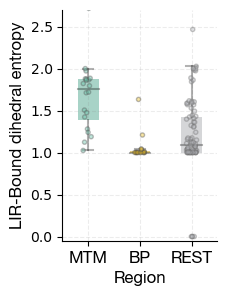

In [24]:
# Create the boxplot
fig, ax = plt.subplots(figsize=(2,3))
PROPS = {
    'boxprops':{ 'edgecolor':'none', 'alpha':0.6},
    'medianprops':{'color':'black','alpha':0.3},
    'whiskerprops':{'color':'black','alpha':0.3},
    'capprops':{'color':'black','alpha':0.3}}
col_ls=['#63C2A7','#EDBE1F','#B8BAC0' ]


sns.boxplot(x='Region', y='bnd_ord', data=ord_region_wise, 
            showfliers=False,width=0.4,palette=col_ls,
            **PROPS,ax=ax)

sns.stripplot(x='Region', y='bnd_ord', data=ord_region_wise, 
              jitter=True, alpha=0.4, 
              dodge=False, palette=col_ls,
              size=3,linewidth=1,ax=ax)



ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.15)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.15)

#ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticks([0,1,2], ['MTM', 'BP', 'REST'])
ax.set_xticklabels(['MTM', 'BP', 'REST'], fontdict=font)

# ax.set_yticks([0,0.2,0.4,0.6], [0,0.2,0.4,0.6])
# ax.set_yticklabels([0,0.2,0.4,0.6], fontdict=font)


ax.set_xlabel('Region', fontdict=font)
ax.set_ylabel('LIR-Bound dihedral entropy', fontdict=font)

ax.set_ylim(-0.05,2.7)


plt.savefig('../../../plots/dihedrals/dihedral_entropy_calculations/dihedral_entropy_region_wise_bnd.png', dpi=550,
           transparent=True, bbox_inches='tight')

In [25]:
ord_region_wise_compressed=pd.DataFrame()
ord_region_wise_compressed["Region"]=ord_region_wise["Region"].to_list()+ord_region_wise["Region"].to_list()
ord_region_wise_compressed["net_ent"]=ord_region_wise["pre_ord"].to_list()+ord_region_wise["bnd_ord"].to_list()
ord_region_wise_compressed["state"]=["Cyto" for i in ord_region_wise["pre_ord"]]+\
                                    ["LIR-BOUND" for i in ord_region_wise["bnd_ord"]]
ord_region_wise_compressed

,Region,net_ent,state
0,MTM,2.163755,Cyto
1,MTM,1.223384,Cyto
2,MTM,1.882457,Cyto
3,MTM,1.868262,Cyto
4,MTM,1.493937,Cyto
...,...,...,...
233,REST,1.005508,LIR-BOUND
234,REST,1.994838,LIR-BOUND
235,REST,1.591231,LIR-BOUND
236,REST,1.999724,LIR-BOUND


/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


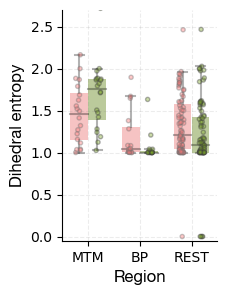

In [26]:
# Create the boxplot
fig, ax = plt.subplots(figsize=(2,3))
PROPS = {
    'boxprops':{ 'edgecolor':'none', 'alpha':0.5},
    'medianprops':{'color':'black','alpha':0.3},
    'whiskerprops':{'color':'black','alpha':0.3},
    'capprops':{'color':'black','alpha':0.3}}
#col_ls=['#63C2A7','#EDBE1F','#B8BAC0' ]

col_ls=["#FF7878","#7DA629"]
box=sns.boxplot(x='Region', y='net_ent', data=ord_region_wise_compressed, hue="state",
            showfliers=False,width=0.7,palette=col_ls,
            **PROPS,ax=ax)
# sns.catplot(kind="box", x="Region", y="net_ent", hue="state", data=ord_region_wise_compressed, 
#                 dodge=True,showfliers=False,palette=col_ls,**PROPS,ax=ax)

sns.stripplot(x='Region', y='net_ent', data=ord_region_wise_compressed, hue="state",
              jitter=True, alpha=0.4, 
              dodge=True, palette=col_ls,
              size=3,linewidth=1,ax=ax)



ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.15)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.15)

#ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ax.set_xticks([0,1,2], ['MTM', 'BP', 'REST'])
# ax.set_xticklabels(['MTM', 'BP', 'REST'], fontdict=font)

# ax.set_yticks([0,0.2,0.4,0.6], [0,0.2,0.4,0.6])
# ax.set_yticklabels([0,0.2,0.4,0.6], fontdict=font)


ax.set_xlabel('Region', fontdict=font)
ax.set_ylabel('Dihedral entropy', fontdict=font)

ax.set_ylim(-0.05,2.7)


box.legend_.remove()
# plt.legend()

plt.savefig('../../../plots/dihedrals/dihedral_entropy_calculations/dihedral_entropy_regionwise_pre_bnd_BB_CHI1_considered.png', dpi=550,
           transparent=True, bbox_inches='tight')

/var/folders/pp/z1pgcq157pjgg48m2cg7wwkh0000gn/T/ipykernel_41014/133870571.py:17: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(x='state', y='net_ent', data=ord_region_wise_compressed,
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of

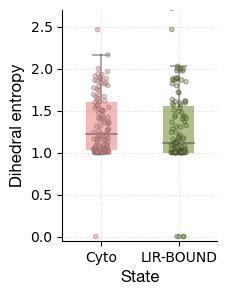

In [27]:
# Create the boxplot
fig, ax = plt.subplots(figsize=(2,3))
PROPS = {
    'boxprops':{ 'edgecolor':'none', 'alpha':0.6},
    'medianprops':{'color':'black','alpha':0.3},
    'whiskerprops':{'color':'black','alpha':0.3},
    'capprops':{'color':'black','alpha':0.3}}
#col_ls=['#63C2A7','#EDBE1F','#B8BAC0' ]

col_ls=["#FF7878","#7DA629"]
box=sns.boxplot(x='state', y='net_ent', data=ord_region_wise_compressed,
            showfliers=False,width=0.4,palette=col_ls,
            **PROPS,ax=ax)
# sns.catplot(kind="box", x="Region", y="net_ent", hue="state", data=ord_region_wise_compressed, 
#                 dodge=True,showfliers=False,palette=col_ls,**PROPS,ax=ax)

sns.stripplot(x='state', y='net_ent', data=ord_region_wise_compressed,
              jitter=True, alpha=0.4, 
              dodge=False, palette=col_ls,
              size=3,linewidth=1,ax=ax)



ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.15)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.15)

#ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ax.set_xticks([0,1,2], ['MTM', 'BP', 'REST'])
# ax.set_xticklabels(['MTM', 'BP', 'REST'], fontdict=font)

# ax.set_yticks([0,0.2,0.4,0.6], [0,0.2,0.4,0.6])
# ax.set_yticklabels([0,0.2,0.4,0.6], fontdict=font)


ax.set_xlabel('State', fontdict=font)
ax.set_ylabel('Dihedral entropy', fontdict=font)

ax.set_ylim(-0.05,2.7)


# plt.legend()

plt.savefig('../../../plots/dihedrals/dihedral_entropy_calculations/dihedral_entropy_overall_pre_bnd_BB_CHI1_considered.png', dpi=550,
           transparent=True, bbox_inches='tight')

In [28]:
#pre_entropy_merger2
#bnd_entropy_merger2

In [29]:
MTM_all=[1,2,3,4,5,6,7,8,9,10,12,36,37,38,39,40,41,42,43,44,46,80,82,84,85,112,114,115,116,117,118,119] 
MTM_core=[1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 37, 38, 39, 40, 41, 42, 43, 45, 46, 119]
MTM_vicinity=[i for i in MTM_all if i not in MTM_core]
triad_res=[59,60,61,64,68]+[i for i in range(71,80)]+[i for i in range(83,93)]
HP1=[19,23,32,34,51,53,108]
HP2=[35,52,54,55,58,63,66,67,70]

In [30]:
def reg_entropy_returner(region, state):
    
    if state=="PRE":
        reg_ent_ls=[]
        for res, ent in zip(pre_entropy_merger2['Residues'],
                           pre_entropy_merger2['NET_ENTROPY']):
            
            if res in region:
                reg_ent_ls.append(ent)
    
    elif state=="BND":
        reg_ent_ls=[]
        for res, ent in zip(bnd_entropy_merger2['Residues'],
                           bnd_entropy_merger2['NET_ENTROPY']):
            
            if res in region:
                reg_ent_ls.append(ent)
                
    else:
        raise ValueError("Enter correct state defnition PRE/BND ")
    
    
    return reg_ent_ls

In [31]:
def reg_dentropy_returner(region):
    reg_dent_ls=[]
    for res, d_ent in zip([i for i in range(1,121)],d_ent_pre_bnd):
        if res in region:
            reg_dent_ls.append(d_ent)

    return reg_dent_ls

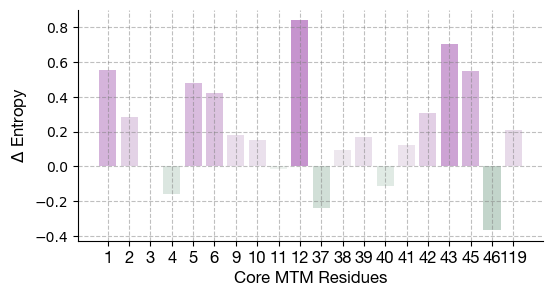

In [32]:
font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':12
   }


col_ls_reg=[]
for j in reg_dentropy_returner(MTM_core):
    col=f2rgb2.to_rgba(j)[:3]
    col_ls_reg.append(col)
    
fig, ax = plt.subplots(figsize=(6,3))

ax.bar([str(i) for i in MTM_core],
         reg_dentropy_returner(MTM_core),color=col_ls_reg)



ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_visible(False)
# ax.spines['left'].set_visible(False)

# ax.set_yticks([])
# ax.set_xticks([])
#ax.set_xlim(0,15)

# ax.set_yticks([-1.5,-1,-0.5,0,0.5,1,1.5],
#              [-1.5,-1,-0.5,0,0.5,1,1.5],fontdict=font)

# ax.set_yticks([res_ for res_ in [i for i in range (1,120)]],
#               [str(res_) for res_ in [i for i in range (1,120)]]
#               ,fontdict=font, 
#              rotation=0)

ax.set_xticks([i for i in range(len(MTM_core))],
              [str(res_) for res_ in MTM_core]
              ,fontdict=font, 
             rotation=0)

ax.set_ylabel('$\Delta$ Entropy', fontdict=font)
ax.set_xlabel('Core MTM Residues', fontdict=font)
#ax.set_ylim(-1.6, 1.6)
# ax.set_ylim(-1, 121)

ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.5)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.5)
ax.xaxis.grid(which = 'minor',linestyle='dashed',alpha=0.5)
ax.yaxis.grid(which = 'minor',linestyle='dashed',alpha=0.5)
plt.savefig("../../../plots/dihedrals/dihedral_entropy_calculations/MTM_d_entropy_pre_vs_bnd.png",dpi=550,
           transparent=True, bbox_inches='tight')


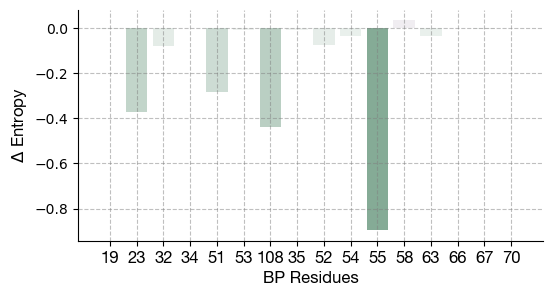

In [33]:
font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':12
   }


col_ls_reg=[]
for j in reg_dentropy_returner(HP1+HP2):
    col=f2rgb2.to_rgba(j)[:3]
    col_ls_reg.append(col)
    
fig, ax = plt.subplots(figsize=(6,3))

ax.bar([str(i) for i in HP1+HP2],
         reg_dentropy_returner(HP1+HP2),color=col_ls_reg)



ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_visible(False)
# ax.spines['left'].set_visible(False)

# ax.set_yticks([])
# ax.set_xticks([])
#ax.set_xlim(0,15)

# ax.set_yticks([-1.5,-1,-0.5,0,0.5,1,1.5],
#              [-1.5,-1,-0.5,0,0.5,1,1.5],fontdict=font)

# ax.set_yticks([res_ for res_ in [i for i in range (1,120)]],
#               [str(res_) for res_ in [i for i in range (1,120)]]
#               ,fontdict=font, 
#              rotation=0)

ax.set_xticks([i for i in range(len(HP1+HP2))],
              [str(res_) for res_ in HP1+HP2]
              ,fontdict=font, 
             rotation=0)

ax.set_ylabel('$\Delta$ Entropy', fontdict=font)
ax.set_xlabel('BP Residues', fontdict=font)
# ax.set_ylim(-1.6, 1.6)
# ax.set_ylim(-1, 121)

ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.5)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.5)
ax.xaxis.grid(which = 'minor',linestyle='dashed',alpha=0.5)
ax.yaxis.grid(which = 'minor',linestyle='dashed',alpha=0.5)
plt.savefig("../../../plots/dihedrals/dihedral_entropy_calculations/BP_d_entropy_pre_vs_bnd.png",dpi=550,
           transparent=True, bbox_inches='tight')


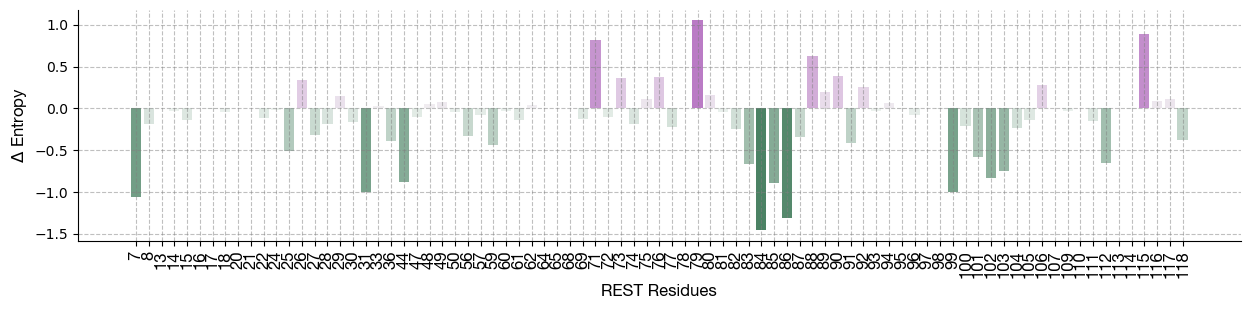

In [34]:
font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':12
   }

REST=[i for i in range(1,120) if i not in MTM_core+HP1+HP2]
col_ls_reg=[]
for j in reg_dentropy_returner(REST):
    col=f2rgb2.to_rgba(j)[:3]
    col_ls_reg.append(col)
    
fig, ax = plt.subplots(figsize=(15,3))

ax.bar([str(i) for i in REST],
         reg_dentropy_returner(REST),color=col_ls_reg)



ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_visible(False)
# ax.spines['left'].set_visible(False)

# ax.set_yticks([])
# ax.set_xticks([])
#ax.set_xlim(0,15)

# ax.set_yticks([-1.5,-1,-0.5,0,0.5,1,1.5],
#              [-1.5,-1,-0.5,0,0.5,1,1.5],fontdict=font)

# ax.set_yticks([res_ for res_ in [i for i in range (1,120)]],
#               [str(res_) for res_ in [i for i in range (1,120)]]
#               ,fontdict=font, 
#              rotation=0)

ax.set_xticks([i for i in range(len(REST))],
              [str(res_) for res_ in REST]
              ,fontdict=font, 
             rotation=90)

ax.set_ylabel('$\Delta$ Entropy', fontdict=font)
ax.set_xlabel('REST Residues', fontdict=font)
# ax.set_ylim(-1.6, 1.6)
# ax.set_ylim(-1, 121)

ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.5)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.5)
ax.xaxis.grid(which = 'minor',linestyle='dashed',alpha=0.5)
ax.yaxis.grid(which = 'minor',linestyle='dashed',alpha=0.5)


plt.savefig("../../../plots/dihedrals/dihedral_entropy_calculations/REST_d_entropy_pre_vs_bnd.png",dpi=550,
           transparent=True, bbox_inches='tight')


In [35]:
# fil=ord_region_wise_compressed[ord_region_wise_compressed["state"]=="Cyto"]
fil_2=ord_region_wise_compressed[ord_region_wise_compressed["Region"]=="REST"]
fil_2


,Region,net_ent,state
36,REST,1.060809,Cyto
37,REST,1.259553,Cyto
38,REST,1.000000,Cyto
39,REST,1.046034,Cyto
40,REST,1.166063,Cyto
...,...,...,...
233,REST,1.005508,LIR-BOUND
234,REST,1.994838,LIR-BOUND
235,REST,1.591231,LIR-BOUND
236,REST,1.999724,LIR-BOUND


In [36]:
np.percentile(fil_2[fil_2["state"]=="Cyto"]["net_ent"], [25, 75]),\
np.percentile(fil_2[fil_2["state"]=="LIR-BOUND"]["net_ent"], [25, 75])

(array([1.03642314, 1.58016158]), array([1.        , 1.42682264]))

In [37]:
fil_2=ord_region_wise_compressed[ord_region_wise_compressed["Region"]=="MTM"]
fil_2[fil_2["state"]=="Cyto"]["net_ent"].sum()/len(fil_2[fil_2["state"]=="Cyto"]["net_ent"]),\
fil_2[fil_2["state"]=="LIR-BOUND"]["net_ent"].sum()/len(fil_2[fil_2["state"]=="LIR-BOUND"]["net_ent"])

(1.4589869301398644, 1.6677279813207124)

In [38]:
fil_2=ord_region_wise_compressed[ord_region_wise_compressed["Region"]=="MTM"]
fil_2[fil_2["state"]=="Cyto"]["net_ent"].std()/len(fil_2[fil_2["state"]=="Cyto"]["net_ent"]),\
fil_2[fil_2["state"]=="LIR-BOUND"]["net_ent"].std()/len(fil_2[fil_2["state"]=="LIR-BOUND"]["net_ent"])

(0.01780872582438859, 0.01970894933653719)

In [39]:
MTM_all=[1,2,3,4,5,6,7,8,9,10,12,36,37,38,39,40,41,42,43,44,46,80,82,84,85,112,114,115,116,117,118,119] 
MTM_core=[1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 37, 38, 39, 40, 41, 42, 43, 45, 46, 119]
MTM_vicinity=[i for i in MTM_all if i not in MTM_core]
triad_res=[59,60,61,64,68]+[i for i in range(71,80)]+[i for i in range(83,93)]
HP1=[19,23,32,34,51,53,108]
HP2=[35,52,54,55,58,63,66,67,70]

In [40]:
rest=[i for i in range(1,120) if i not in MTM_core+HP1+HP2]

In [41]:
d_ent_pre_bnd_df=pd.DataFrame()
d_ent_pre_bnd_df['Residues']=[i for i in range(1,120)]
d_ent_pre_bnd_df['d_Entropy']=d_ent_pre_bnd
d_ent_pre_bnd_df.iloc[[i-1 for i in rest]]["d_Entropy"].sum()

-10.80007672177467

In [42]:

total_mtm_d_ent=d_ent_pre_bnd_df.iloc[[i-1 for i in MTM_core]]["d_Entropy"].sum()
total_bp_d_ent=d_ent_pre_bnd_df.iloc[[i-1 for i in HP1+HP2]]["d_Entropy"].sum()
total_rest_d_ent=d_ent_pre_bnd_df.iloc[[i-1 for i in rest]]["d_Entropy"].sum()

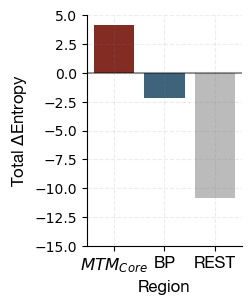

In [43]:
font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':12
   }



fig, ax = plt.subplots(figsize=(2,3))


ax.bar([0,1,2],[total_mtm_d_ent, total_bp_d_ent, 
               total_rest_d_ent], color=["#76150C","#29526D","#B4B4B4"],
      alpha=0.9)
ax.axhline(y=0, color="black",alpha=0.4)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.15)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.15)



#ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticks([0,1,2], ['$MTM_{Core}$', 'BP', 'REST'])
ax.set_xticklabels(['$MTM_{Core}$', 'BP', 'REST'], fontdict=font)

# ax.set_yticks([0,0.2,0.4,0.6], [0,0.2,0.4,0.6])
# ax.set_yticklabels([0,0.2,0.4,0.6], fontdict=font)

ax.set_ylim([-15,5])
ax.set_xlabel('Region', fontdict=font)
ax.set_ylabel('Total $\Delta$Entropy', fontdict=font)

plt.savefig('../../../plots/dihedrals/dihedral_entropy_calculations/total_diff_dihedral_entropy_region_wise_bnd_vs_pre.png', dpi=550,
           transparent=True, bbox_inches='tight')

In [44]:
total_mtm_d_ent, total_bp_d_ent, total_rest_d_ent

(4.174821023616965, -2.2195851846438304, -10.80007672177467)

In [80]:

total_mtm_n_ter_ent=d_ent_pre_bnd_df.iloc[[i-1 for i in [i for i in range(1,13)]]]["d_Entropy"].sum()
total_mtm_l3_ent=d_ent_pre_bnd_df.iloc[[i-1 for i in [37, 38, 39, 40, 41, 42, 43, 45, 46]]]["d_Entropy"].sum()


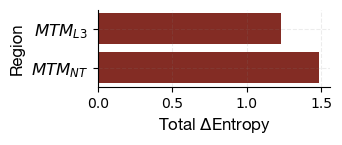

In [88]:
font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':12
   }



fig, ax = plt.subplots(figsize=(3,1))


ax.barh([0,1],[total_mtm_n_ter_ent, total_mtm_l3_ent], color="#76150C",
      alpha=0.9)
ax.axvline(x=0, color="black",alpha=0.4)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.15)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.15)



#ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_yticks([0,1], ['$MTM_{NT}$', '$MTM_{L3}$'])
ax.set_yticklabels(['$MTM_{NT}$', '$MTM_{L3}$'], fontdict=font)

# ax.set_yticks([0,0.2,0.4,0.6], [0,0.2,0.4,0.6])
# ax.set_yticklabels([0,0.2,0.4,0.6], fontdict=font)

#ax.set_ylim([-15,5])
ax.set_ylabel('Region', fontdict=font)
ax.set_xlabel('Total $\Delta$Entropy', fontdict=font)

plt.savefig('../../../plots/dihedrals/dihedral_entropy_calculations/total_diff_dihedral_entropy_MTM_bnd_vs_pre.png', dpi=550,
           transparent=True, bbox_inches='tight')

In [128]:
pwd

'/Volumes/Seagate Hub/LC3_conformations_scripts_data/scripts/dihedrals/dihedral_entropy_calculations'

In [131]:
for i in d_ent_pre_bnd:
    print(abs(i))

0.5529079776865018
0.28187597936675757
0.004789918122998671
0.1565892897362271
0.47694390730021397
0.4225771090038031
1.060809383739294
0.18184572281728983
0.1782754517919669
0.15461914334797955
0.015393638343409233
0.8398327876525591
0.0
0.029040723604232488
0.14261435016058543
0.0
0.005789064265927513
0.03977767879742222
0.004352070610022629
0.0
0.0047143801420801434
0.12031218606118288
0.37481999128054033
0.01722356279526638
0.5073913834425183
0.33566419937248027
0.31335581143597135
0.18255008861122435
0.1431104938510881
0.15718920472354836
1.0
0.08184505407891884
0.032351755904917345
0.0
0.28207988388583427
0.39428146344686565
0.24077356564448626
0.09480831095302955
0.1709421912124911
0.1141603193863232
0.12618666682203705
0.3072047047919475
0.7046021351068592
0.8780719121284171
0.5507431649723782
0.36599946720543897
0.10193036839185221
0.051261094113414174
0.07252207056199578
0.048619640358568805
0.01093642028693198
0.43820827036524945
0.010778081694387431
0.07417399909497369
0.03

In [132]:
max([abs(i) for i in d_ent_pre_bnd])

1.460410537537052